# Análise Arquiteturas Timeloop

In [217]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast

# --- CONFIGURAÇÃO ESPECIAL PARA SLIDES (PPT) ---
# O segredo: Tamanho de figura MENOR (10x6) + Fonte GRANDE (16+)
# Isso faz o texto parecer "gigante" em relação ao gráfico.
plt.rcParams.update({'font.size': 22})       
plt.rcParams['axes.titlesize'] = 24          
plt.rcParams['axes.labelsize'] = 22        
plt.rcParams['xtick.labelsize'] = 16        
plt.rcParams['ytick.labelsize'] = 16     
plt.rcParams['legend.fontsize'] = 16      # Legenda um pouco menor para não tapar o gráfico

# Carregar dados
df = pd.read_csv('dse_pe_mac_width/dse_results.csv', sep=';')

# Funções auxiliares
def parse_arch(s):
    parts = s.split('_')
    return int(parts[0]), int(parts[2]), int(parts[4])

def parse_dict_col(s):
    try: return ast.literal_eval(s)
    except: return {}

df['neurons'], df['macs'], df['width'] = zip(*df['arquitecture'].apply(parse_arch))
df['area_dict'] = df['per_component_area'].apply(parse_dict_col)

## Fronteira de Pareto (Área vs. Latência):
Por que é interessante: É o gráfico mais importante para engenharia. Mostra o compromisso (trade-off) entre o tamanho do chip (custo) e a velocidade (latência). Os pontos mais próximos do canto inferior esquerdo são os melhores designs "ótimos".

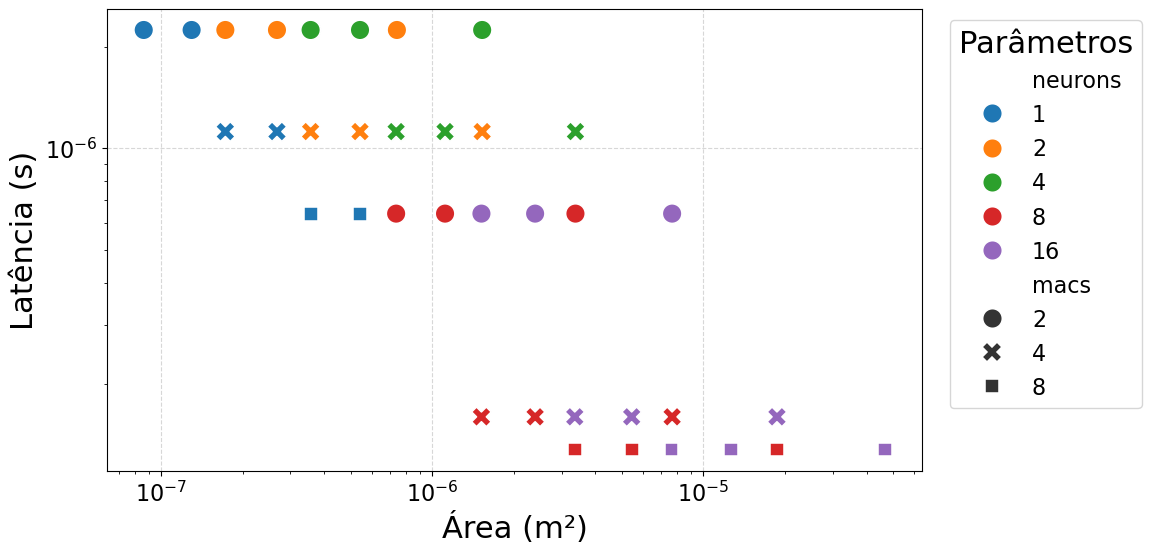

In [219]:
# --- GRÁFICO 1: PARETO (Slide Size) ---
plt.figure(figsize=(12, 6)) 
sns.scatterplot(data=df, x='area', y='latency', hue='neurons', style='macs', palette='tab10', s=200)
# plt.title('Fronteira de Pareto')
plt.xlabel('Área (m²)')
plt.ylabel('Latência (s)')
plt.xscale('log'); plt.yscale('log')
plt.grid(True, ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Parâmetros')
plt.tight_layout()
plt.show()

## Matriz de Correlação:
Por que é interessante: Um mapa de calor que mostra como as variáveis de entrada ('neurons', 'macs', 'width') influenciam as saídas. 
Por exemplo: "Aumentar a largura (width) aumenta linearmente a energia?"

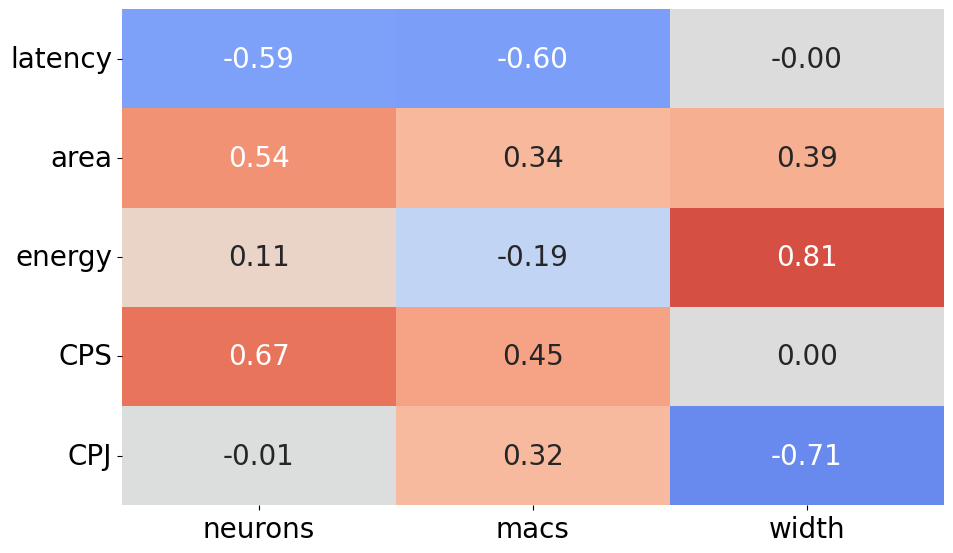

In [214]:
# --- GRÁFICO 4: MATRIZ DE IMPACTO ---
     
plt.rcParams['xtick.labelsize'] = 20    
plt.rcParams['ytick.labelsize'] = 20   

inputs = ['neurons', 'macs', 'width']
outputs = ['latency', 'area', 'energy', 'computes_per_second', 'computes_per_joule']

# 1. Calcula a correlação
corr_matrix = df[inputs + outputs].corr().loc[outputs, inputs]

# 2. RENOMEIA O RÓTULO AQUI
# Você pode usar um dicionário para mapear o nome antigo para o novo
corr_matrix = corr_matrix.rename(index={'computes_per_second': 'CPS'})
corr_matrix = corr_matrix.rename(index={'computes_per_joule': 'CPJ'})

# (Opcional) Se quiser mudar também o computes_per_joule:
# corr_matrix = corr_matrix.rename(index={'computes_per_second': 'CPS', 'computes_per_joule': 'CPJ'})

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, annot_kws={"size": 20}, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, cbar=False)
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

## Eficiência (Throughput vs. Eficiência Energética):
Por que é interessante: Compara o desempenho bruto (computes_per_second) contra o consumo (computes_per_joule). Ajuda a identificar arquiteturas que são rápidas sem gastar energia excessiva.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# Configuração de Fonte para Slides
plt.rcParams.update({'font.size': 22})    
plt.rcParams['legend.fontsize'] = 18 

# 1. Preparar Dados
# Tenta ler no diretório atual (ambiente Canvas), senão tenta no subdiretório (seu local)
try:
    df = pd.read_csv('dse_results.csv', sep=';')
except FileNotFoundError:
    try:
        df = pd.read_csv('dse_pe_mac_width/dse_results.csv', sep=';')
    except FileNotFoundError:
        print("Erro: Arquivo dse_results.csv não encontrado.")
        df = pd.DataFrame(columns=['arquitecture', 'computes_per_second', 'computes_per_joule'])

def parse_arch(s):
    try:
        parts = s.split('_')
        return int(parts[0]), int(parts[2]), int(parts[4])
    except:
        return 0, 0, 0

if not df.empty:
    df['neurons'], df['macs'], df['width_'] = zip(*df['arquitecture'].apply(parse_arch))

    # Criar rótulos claros para a Largura
    df['width'] = df['width_'].apply(lambda x: f" {x}")
    # Ordenar corretamente
    width_order = [f" {x}" for x in sorted(df['width_'].unique())]
    df['width'] = pd.Categorical(df['width'], categories=width_order, ordered=True)

    # 2. Plotar Gráfico 2
    plt.figure(figsize=(12, 6))

    ax = sns.scatterplot(
        data=df, 
        x='computes_per_second', 
        y='computes_per_joule', 
        hue='width', # Cor define a Largura
        size='neurons',    # Tamanho define os Neurônios
        sizes=(50, 400),   # Tamanho visual das bolinhas no gráfico (max 400)
        palette='tab10'
    )

    # plt.title('Desempenho vs. Eficiência')
    plt.xlabel('OPS')
    plt.ylabel('Eficiência (OPS/Joule)')
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, ls="--", alpha=0.5)

    # 3. Ajuste Fino da Legenda
    # Criamos a legenda normalmente
    leg = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Parâmetros')

    # Correção de compatibilidade para pegar os handles (ícones) da legenda
    handles = getattr(leg, 'legend_handles', getattr(leg, 'legendHandles', []))

    for text, handle in zip(leg.get_texts(), handles):
        # Se o texto da legenda contém "Largura", é um indicador de cor -> AUMENTA
        if " " in text.get_text():
            # --- CORREÇÃO DO ERRO 'Line2D' ---
            # Verifica se o handle suporta 'set_sizes' (PathCollection) ou 'set_markersize' (Line2D)
            if hasattr(handle, 'set_sizes'):
                handle.set_sizes([800.0]) # Área grande
            elif hasattr(handle, 'set_markersize'):
                # Line2D usa diâmetro, não área. sqrt(800) é aprox 28. Usaremos 30.
                handle.set_markersize(15) 
            
        # Se for "Neurônios" (ou números), o loop passa direto e mantém o tamanho original

    plt.tight_layout()
    plt.savefig('efficiency_corrected_legend.png')
    plt.show()

## Decomposição de Área por Componente (Barras Empilhadas):
Por que é interessante: O ficheiro contém dicionários na coluna per_component_area. Este gráfico "abre" esses dados para mostrar quanto espaço cada peça (como GlobalBuffer ou MACC) está a ocupar no chip.

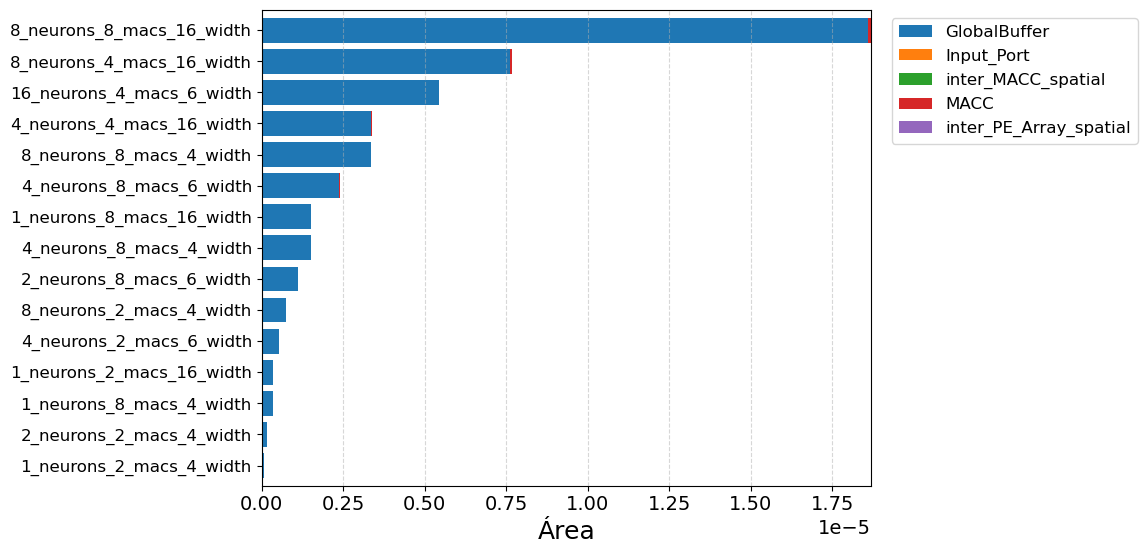

In [142]:
# --- GRÁFICO 3: DECOMPOSIÇÃO (Barras Horizontais) ---
# DICA: Barras horizontais funcionam melhor em slides para ler os nomes!

plt.rcParams.update({'font.size': 22})       
plt.rcParams['axes.titlesize'] = 24          
plt.rcParams['axes.labelsize'] = 18       
plt.rcParams['xtick.labelsize'] = 14    
plt.rcParams['ytick.labelsize'] = 12   
plt.rcParams['legend.fontsize'] = 12  # Legenda um pouco menor para não tapar o gráfico

area_breakdown = pd.DataFrame(df['area_dict'].tolist())
area_breakdown['arquitecture'] = df['arquitecture']
area_breakdown['total_area'] = df['area']
subset_area = area_breakdown.sort_values('total_area').iloc[::3]

plt.figure(figsize=(12, 6)) # Um pouco mais largo para caber os nomes
# kind='barh' faz barras horizontais
subset_area.set_index('arquitecture').drop(columns=['total_area']).plot(kind='barh', stacked=True, width=0.8, ax=plt.gca())
# plt.title('Decomposição de Área')
plt.xlabel('Área')
plt.ylabel('') 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()